В блокноте проверяется функция для выравнивания лица по ключевым точкам и создается датасет с выравненными лицами 224 * 224 на 1000 чел.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.transform import SimilarityTransform
import cv2
from sklearn.model_selection import train_test_split

Функция для выравнивания лица, в ней используется алгоритм Умеямы из skimage (по мотивам https://github.com/deepinsight/insightface/blob/master/python-package/insightface/utils/face_align.py).

In [2]:
arcface_dst = np.array(
    [[38.2946, 51.6963], [73.5318, 51.5014], [56.0252, 71.7366],
     [41.5493, 92.3655], [70.7299, 92.2041]],
    dtype=np.float32) * 2

def get_aligned(image, landmarks):
    dst_landmarks = arcface_dst
    transform = SimilarityTransform.from_estimate(landmarks, dst_landmarks)
    M = transform.params[0:2, :]
    transformed_image = cv2.warpAffine(image, M, (224, 224))
    return transformed_image

def get_aligned_l(image, landmarks):
    dst_landmarks = arcface_dst
    transform = SimilarityTransform.from_estimate(landmarks, dst_landmarks)
    M = transform.params[0:2, :]
    transformed_image = cv2.warpAffine(image, M, (224, 224))
    transformed_landmarks = cv2.transform(landmarks[np.newaxis], M).squeeze(axis=0)
    return transformed_image, transformed_landmarks


Проверим на картинках и точках из датасета. На выравненных картинках показаны реальные точки (синим) и референсные точки для выравнивания (красным).

In [3]:
mark_df = pd.read_csv('./CelebA/Anno/list_landmarks_celeba.txt', header=1, sep='\\s+')

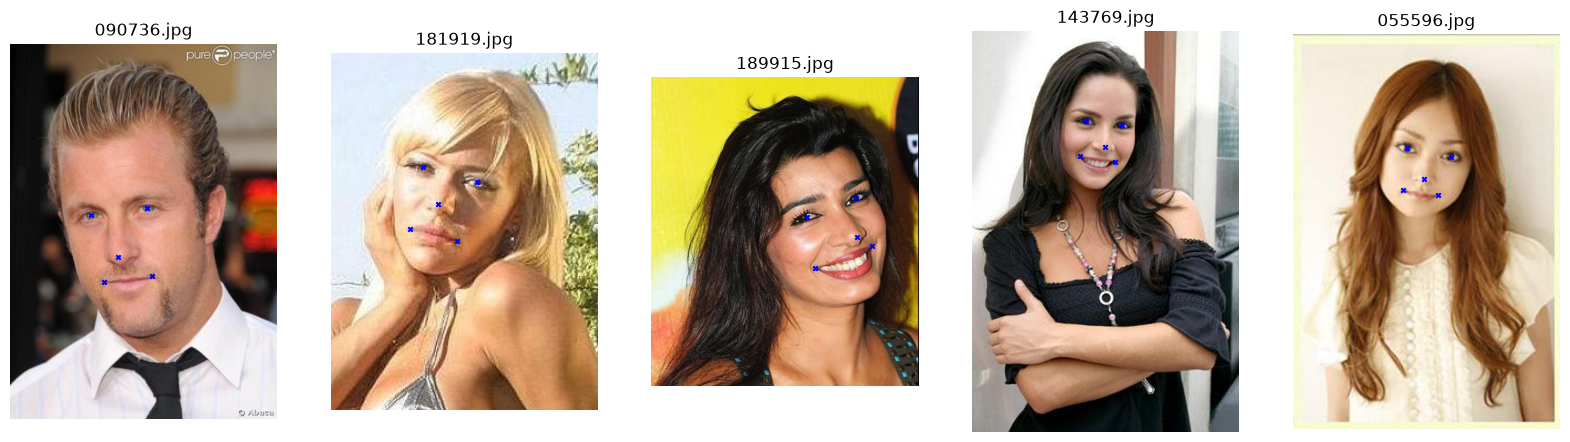

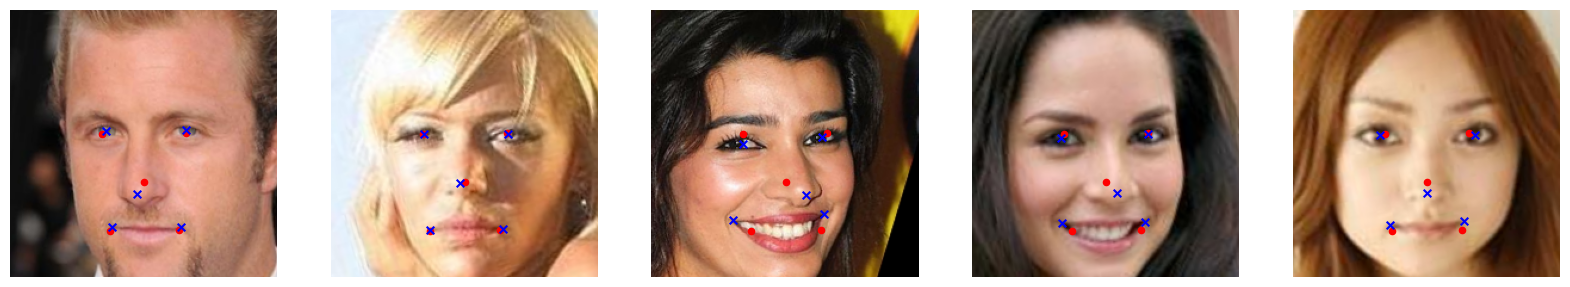

In [4]:
n = 5
samples = mark_df.sample(n)

names = [samples.index[i] for i in range(n)]
landmarks = [np.asarray(samples.iloc[i], dtype=float).reshape(-1, 2) for i in range(n)]
images = [np.asarray(Image.open(f'CelebA/Img/img_celeba/{names[i]}')) for i in range(n)]

plt.figure(figsize=(20, 10))
for i in range(n):
    plt.subplot(1, n, i + 1)
    plt.imshow(images[i])
    plt.scatter(landmarks[i][:, 0], landmarks[i][:, 1], s=10, marker='x', c='b')
    plt.title(names[i])
    plt.axis("off")

plt.show()

plt.figure(figsize=(20, 5))
for i in range(n):
    transformed_image, transformed_landmarks = get_aligned_l(images[i], landmarks[i])

    plt.subplot(1, n, i + 1)
    plt.imshow(transformed_image)
    plt.scatter(arcface_dst[:, 0], arcface_dst[:, 1], s=20, marker='o', c='r')
    plt.scatter(transformed_landmarks[:, 0], transformed_landmarks[:, 1], s=30, marker='x', c='b')
    plt.axis("off")

plt.show()


Дальше строится датасет. Сначала посмотрим, сколько картинок у каких личностей.

In [5]:
id_df = pd.read_csv('./CelebA/Anno/identity_CelebA.txt', header=None, sep='\\s+')
id_df

,0,1
0,000001.jpg,2880
1,000002.jpg,2937
2,000003.jpg,8692
3,000004.jpg,5805
4,000005.jpg,9295
...,...,...
202594,202595.jpg,9761
202595,202596.jpg,7192
202596,202597.jpg,9852
202597,202598.jpg,5570


In [6]:
size_df = id_df.groupby(1).size().reset_index(name='size')
size_df

,1,size
0,1,29
1,2,8
2,3,25
3,4,22
4,5,20
...,...,...
10172,10173,30
10173,10174,30
10174,10175,30
10175,10176,30


In [7]:
size_df['size'].value_counts()

size
30    2343
20    1044
21     565
29     493
22     419
23     369
25     361
2      324
24     290
19     288
3      245
5      221
4      221
16     219
18     217
28     216
14     210
6      207
10     202
11     199
9      187
7      183
8      176
13     176
17     173
15     172
12     165
27     125
26     106
1       44
31       9
35       3
32       3
34       2
Name: count, dtype: int64

Самое популярное число картинок у одной личности 30, и таких больше 2000, выберем из них 1000 для датасета.

In [8]:
id_list = set(size_df[size_df['size'] == 30].sample(1000)[1].values)

In [9]:
df = id_df[id_df[1].isin(id_list)]
df

,0,1
1,000002.jpg,2937
2,000003.jpg,8692
3,000004.jpg,5805
8,000009.jpg,3332
17,000018.jpg,2464
...,...,...
202575,202576.jpg,5471
202576,202577.jpg,9246
202578,202579.jpg,8715
202594,202595.jpg,9761


Разобьем датасет на train/val/test в пропорциях 80/10/10, это будет по 24 картинки для обучения и по 3 картинки для валидации и теста по каждой личности.

In [10]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df[1])
val_df, test_df = train_test_split(val_df, test_size=0.5, stratify=val_df[1])

train_df = train_df.sort_index().reset_index(drop=True)
val_df = val_df.sort_index().reset_index(drop=True)
test_df = test_df.sort_index().reset_index(drop=True)


Сохраняем все на диск по папкам по identity. В корне будут файлы со списком картинок.

In [11]:
df_to_process = [train_df, val_df, test_df]
path_to_process = ['aligned/train/', 'aligned/val/', 'aligned/test/']

for path in path_to_process:
    os.makedirs(path, exist_ok=True)
    for id in id_list:
        os.makedirs(f'{path}{id}', exist_ok=True)

train_df.to_csv('aligned/train_identity.csv', index=False, header=False)
val_df.to_csv('aligned/val_identity.csv', index=False, header=False)
test_df.to_csv('aligned/test_identity.csv', index=False, header=False)


In [12]:
for df, path in zip(df_to_process, path_to_process):
    for row in df.itertuples():
        image_name = row._1
        image_path = f'CelebA/Img/img_celeba/{image_name}'
    
        image = np.asarray(Image.open(image_path))
        landmarks = np.asarray(mark_df.loc[image_name]).reshape(-1, 2)

        aligned_image = get_aligned(image, landmarks)

        out_path = f'{path}{row._2}/{image_name}'
        Image.fromarray(aligned_image).save(out_path)
